# 1. ECG data processing pipeline

## Analysis plan

**Starting point:** The file `ECGu.txt` contains 6,500 rows and three columns of raw ECG measurements.

**Final goal:** Display the ECG signals with amplitude in millivolts and time in seconds.

The analysis will follow these steps:

1. Import the necessary libraries.
2. Load the raw ECG data.
3. Check the values and dimensions of the data.
4. Plot the raw ECG data.
5. Convert the ECG amplitude into millivolts.
6. Create a time axis in seconds.
7. Plot the rescaled ECG signals.
8. Improve the readability of the code.
9. Create a realistic ECG plot for the optional bonus.

## 2. Load the ECG data

The ECG data must first be loaded into Python so that its values and dimensions can be checked before further analysis.

In [4]:
# Cell 1: imports

# import the necessary libraries for analysis

import numpy as np # NumPy allows for numerical analysis and calculations and its name is shortened to np. 
import matplotlib.pyplot as plt #  The pyplot tool is accessed through Matplotlib and is used to plot/graph the data and is shortened to plt. 

In [5]:
# CELL 2: load the data into a numpy array

# create a variable called data_path to store the path of the data file
data_path = "data/ECGu.txt" #this is the path to locate the data file
raw_ecg_data = np.loadtxt(data_path) # np.loadtxt() loads numerical data from a text file into a NumPy array # https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html

In [6]:
# Cell 3: look at the data (verify that the data is loaded correctly)

print(raw_ecg_data)
print(raw_ecg_data.shape) #shape tells you the dimensions of the loaded data. 6500 rows = 6,500 recorded samples, 3 columns = three ECG columns/leads: I, II and III.

#  When Python displays the array, it hides most of the rows using ..., so you cannot count them visually. .shape lets you verify that the complete file was loaded correctly.


[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


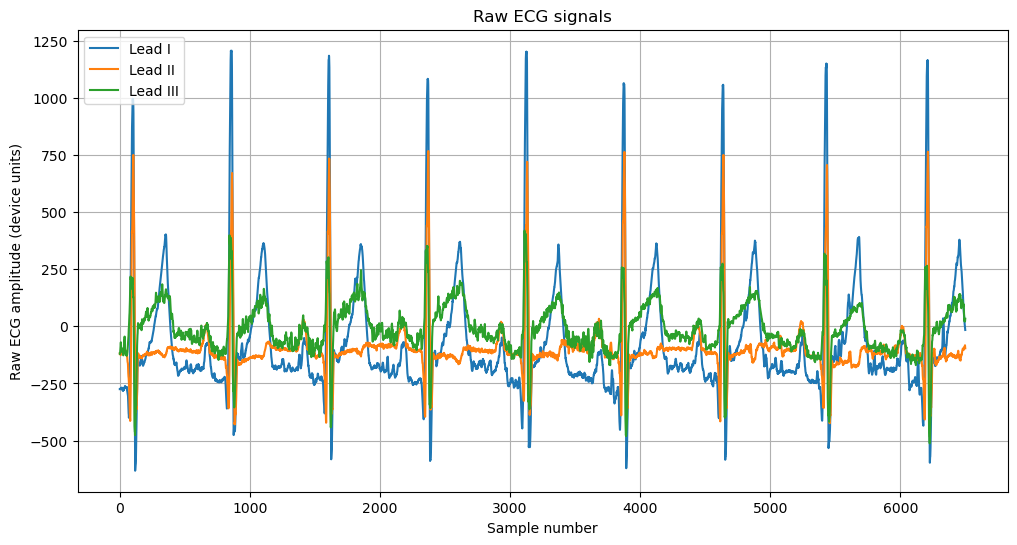

In [7]:
# Cell 1: Plot the raw ECG data that was loaded in the previous step.

# Resources: 
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html

# Plot a new figure that is 12 inches wide and 6 inches high.
plt.figure(figsize=(12, 6))

# Plot every row from the 3 coloumns of ECG data. 
plt.plot(raw_ecg_data[:, 0], label="Lead I") # Plot every row in column 0, for representing Lead I. [:, 0] means all rows from the 1st column (Python counts from zero). Label is displayed in the legend.

plt.plot(raw_ecg_data[:, 1], label="Lead II") # Plot every row in column 1, representing Lead II. [:, 1] means all rows from the 2nd column. Label is displayed in the legend.

plt.plot(raw_ecg_data[:, 2], label="Lead III") # Plot every row in column 2, representing Lead III. [:, 2] means all rows from the 3rd column. Label is displayed in the legend.

# create the x-axis and y-axis labels for the graph
plt.xlabel("Sample number")
plt.ylabel("Raw ECG amplitude (device units)")

# create the title, legend, and grid for the graph
plt.title("Raw ECG signals")
plt.legend()
plt.grid()

plt.show() # displays the completed graph

## Checking that the raw ECG plot is correct

The plot appears correct because it shows three lines, corresponding to the three columns in the dataset and the three recorded ECG leads: I, II, and III. The x-axis runs from 0 to 6,499 and is labeled as "Sample number" which is consistent with the 6,500 rows in the data (the 6,500th row is empty in the data set). 

The signals also contain repeating peaks and patterns rather than remaining constant. The y-axis is still expressed in raw device units because the ECG amplitude has not yet been converted into millivolts.

## 3. Convert the ECG amplitude to millivolts

The ECG values are currently expressed in raw device units. According to the A/D converter gain provided in the instructions, 1,024 raw units correspond to 1 millivolt. The raw values must therefore be divided by 1,024.

$ECG_{mV}$ = $ECG_{raw}$ × 1024 $μV$
 

In [8]:
# Store the converter gain: 1,024 raw units correspond to 1 millivolt.
converter_gain = 1024

# Divide every raw ECG value by the gain to convert it to millivolts.
ecg_data_mv = raw_ecg_data / converter_gain # create a new variable called ecg_data_mv to store the answer 

# Display the converted data to check the result.
ecg_data_mv

array([[-0.26855469, -0.11621094, -0.11621094],
       [-0.26855469, -0.11621094, -0.11621094],
       [-0.26855469, -0.11523438, -0.11816406],
       ...,
       [-0.00390625, -0.08105469,  0.02050781],
       [-0.00878906, -0.0859375 ,  0.03027344],
       [-0.015625  , -0.09375   ,  0.03222656]])

# 4. Converting the time axis to seconds

Using the sampling frequency information, we can convert the time axis to seconds:

$timestamp_s$ = $timestamp_{raw}$ / 100

The data file does not contain a time column. However, the sampling frequency is 1,000 Hz, meaning that 1,000 samples were recorded every second. A sample index can therefore be created for every row and divided by 1,000 to calculate its time in seconds

In [9]:
# Store the sampling frequency in hertz (samples per second).
sampling_frequency_hz = 1000 # # A frequency of 1,000 Hz means that 1,000 samples were recorded per second.

# Obtain the number of rows in the ECG dataset.
number_of_samples = raw_ecg_data.shape[0] # raw_ecg_data.shape gives the dimensions of the data (6500, 3). [0] selects the 1st column, meaning the number of rows: 6,500.

# Create a NumPy array of consecutive sample indices.
sample_indices = np.arange(number_of_samples) # np.arange(6500) creates the integers from 0 up to, but not including, 6,500. This creates indices that run from 0 to 6,499.

# Convert each sample index into seconds. 
time_seconds = sample_indices / sampling_frequency_hz # Divide every sample index by the number of samples recorded per second. # For example, index 6499 / 1000 = 6.499 seconds. NumPy performs this division on every value in the sample_indices array.

# Display the first five time values and the final time value.
print(time_seconds[:5]) # [:5] selects the first five values, at indices 0, 1, 2, 3, and 4.
print(time_seconds[-1]) # [-1] selects the final value in the array.

[0.    0.001 0.002 0.003 0.004]
6.499


# 5. Plot the rescaled ECG data

Now that we have the ECG data in the correct units, we can plot it using Matplotlib.

- time_seconds on the x-axis.
- ecg_data_mv on the y-axis.
- All three ECG leads on the same graph.

The ECG signals are now plotted using time in seconds and amplitude in millivolts. This makes the axes easier to interpret and allows the values to be compared with standard ECG measurements.

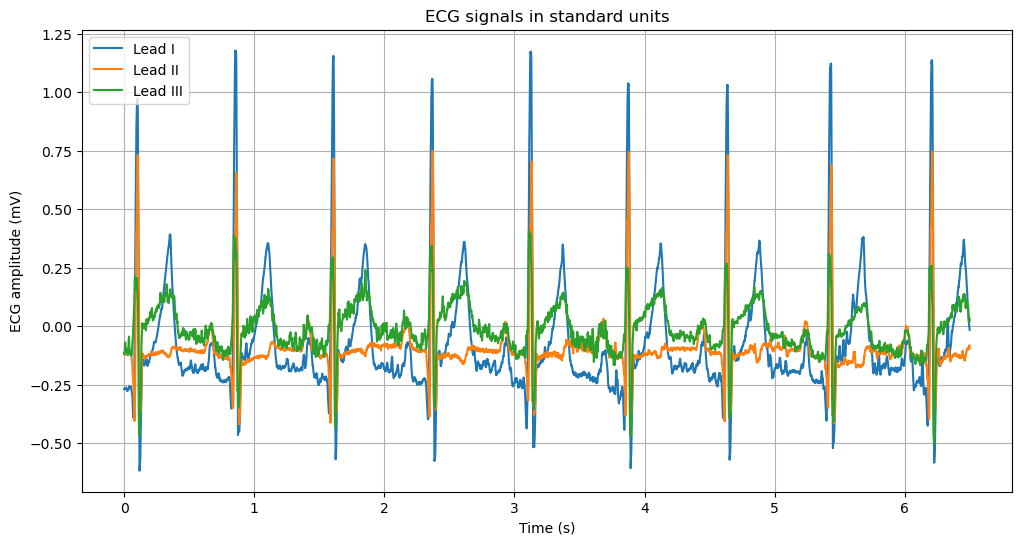

In [10]:
# Matplotlib plotting resources:
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

# Create a new figure that is 12 inches wide and 6 inches high.
plt.figure(figsize=(12, 6))

# Plot time against every ecg value that we converted to mv from all 3 ECG column.
plt.plot(time_seconds, ecg_data_mv[:, 0], label="Lead I") # plot the time in seconds (x-value) and ecg data in mV (y-value) for all rows in column 1. label it as Lead I which will appear in the legend.

plt.plot(time_seconds, ecg_data_mv[:, 1], label="Lead II") # plot the time in seconds (x-value) and ecg data in mV (y-value) for all rows in column 2. label it as Lead II which will appear in the legend.

plt.plot(time_seconds, ecg_data_mv[:, 2], label="Lead III") # # plot the time in seconds (x-value) and ecg data in mV (y-value) for all rows in column 3. label it as Lead III which will appear in the legend.


# Label the x-axis and y-axis of the graph
plt.xlabel("Time (s)")

plt.ylabel("ECG amplitude (mV)")

# Add a title above the graph.
plt.title("ECG signals in standard units")

# Display the labels assigned to the three plotted lines.
plt.legend()

# Add grid lines to make the values easier to read.
plt.grid(True)

# Display the completed graph.
plt.show()

## Checking that the raw ECG plot is correct

- The plot contains three time series, corresponding to the three ECG columns and the three recorded leads: I, II, and III.
- Each signal contains 6,500 samples. At a sampling frequency of 1,000 Hz, this represents 6.5 seconds of recording, with timestamps from 0 to 6.499 seconds.
- The amplitudes range approximately from -0.6 mV to 1.2 mV, so they are on the expected millivolt scale for surface ECG signals. However, ECG amplitude varies between leads and between people, so the graph alone cannot confirm that the ECG is clinically normal. You must observe the ECG data for the same person over a period of time and establish a base and see if there are any changes from the base to conclude any abnormal behabiour. 
- Repeated peaks appear at corresponding times across the three leads, and there are no obvious missing sections or constant signals. This supports that the data and time axis were plotted correctly.

References:

- American Heart Association ECG standardization recommendations: https://www.ahajournals.org/doi/10.1161/CIRCULATIONAHA.108.191097
- University of Utah, characteristics of the normal ECG: https://ecg.utah.edu/lesson/3

## 6. Improve Readability 

The previous sections are kept to show how the ECG analysis was developed step by step. The same analysis is reorganized below using functions.

A function groups instructions that perform one specific task. Once a function has been defined, it can be reused without writing all its instructions again. This reduces repetition and makes the code easier to understand, test, and modify.

Four functions are used:

1. `load_ecg_data` loads the ECG values from the text file.
2. `convert_ecg_to_mv` converts the raw ECG values into millivolts.
3. `create_time_axis` creates one time value for every ECG sample.
4. `plot_ecg_signals` plots all three ECG leads on one graph.

Resources:

- Defining Python functions: https://docs.python.org/3/tutorial/controlflow.html#defining-functions
- Python `enumerate`: https://docs.python.org/3/library/functions.html#enumerate
- NumPy `loadtxt`: https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html
- NumPy `arange`: https://numpy.org/doc/stable/reference/generated/numpy.arange.html
- Matplotlib `plot`: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

In [11]:
# Define a function that loads the ECG data.
def load_ecg_data(file_path): # file_path is the location of the ECG text file.

    # np.loadtxt reads the numerical values from the file and places them in a NumPy array.
    loaded_data = np.loadtxt(file_path)

    # "return" makes loaded_data the final result of this function.
    return loaded_data


# Define a second function that converts the raw ECG values into millivolts.
def convert_ecg_to_mv(raw_ecg_values, converter_gain): # raw_ecg_values contains the original values from the ECG file. converter_gain contains the number of raw units corresponding to 1 mV.

    # Divide every raw ECG value by 1,024.
    converted_ecg_values = raw_ecg_values / converter_gain # e.g.,  -275 / 1024 = approximately -0.269 mV.

    # "return" makes converted_ecg_values the final result of this function.
    return converted_ecg_values 

# Define a third function that creates the time axis. One timestamp in seconds for every ECG sample.
def create_time_axis(number_of_samples, sampling_frequency_hz): # number_of_samples is the number of ECG measurements. sampling_frequency_hz is the number of measurements recorded each second.

    # Create consecutive sample indices from 0 to number_of_samples - 1 (since we want 6,499 indices and not 6,500 as the row is empty and python starts counting at 0.)
    sample_indices = np.arange(number_of_samples) # np.arange creates consecutive numbers starting from zero. In this dataset, number_of_samples is 6,500. This will create  [0, 1, 2, 3, ..., 6499]


    # Convert every sample index into seconds. Divide every sample number by the sampling frequency.
    time_values_seconds = sample_indices / sampling_frequency_hz # The sampling frequency is 1,000 measurements per second. E.g., sample 6499 becomes 6499 / 1000  = 6.499 seconds

    # "return" makes converted_ecg_values the final result of this function.
    return time_values_seconds


# Define a fourth function that plots all the ECG leads on one graph.
def plot_ecg_signals(
    x_values,        #  x-values displayed on the horizontal axis.
    ecg_values,      # ECG y-values displayed on the vertical axis.
    lead_names,      # Names of the ECG leads (I, II, III)
    x_axis_label,    # Text displayed under the horizontal axis.
    y_axis_label,    # Text displayed beside the vertical axis.
    plot_title       # Text displayed above the graph.
):
    # Create an empty area in which the graph will be drawn. 12 inches wide and 6 inches high.
    plt.figure(figsize=(12, 6))

    # Create a for loop that repeats the plotting instructions 3 times, once for every lead name. 
    for lead_index, lead_name in enumerate(lead_names):  # enumerate(lead_names) connects each column number with its name: E.g., column 0 = "Lead I"

        # Draw one ECG lead during each repetition of the loop.

        plt.plot(
            x_values,                   # x_values provides the horizontal positions.    
            ecg_values[:, lead_index],  # " : selects all rows from the current lead column. # lead_index chooses column 0, 1, or 2.
            label=lead_name             # connects the line to its correct lead name.
        )

    # Add x-axis label
    plt.xlabel(x_axis_label)

  # Add y-axis label
    plt.ylabel(y_axis_label)

    # Add a title above the graph.
    plt.title(plot_title)

    # the 3 labels will appear in the legend
    plt.legend()

    # Add grid lines to make the graph easier to read.
    plt.grid(True)

    # Display the completed graph.
    plt.show()

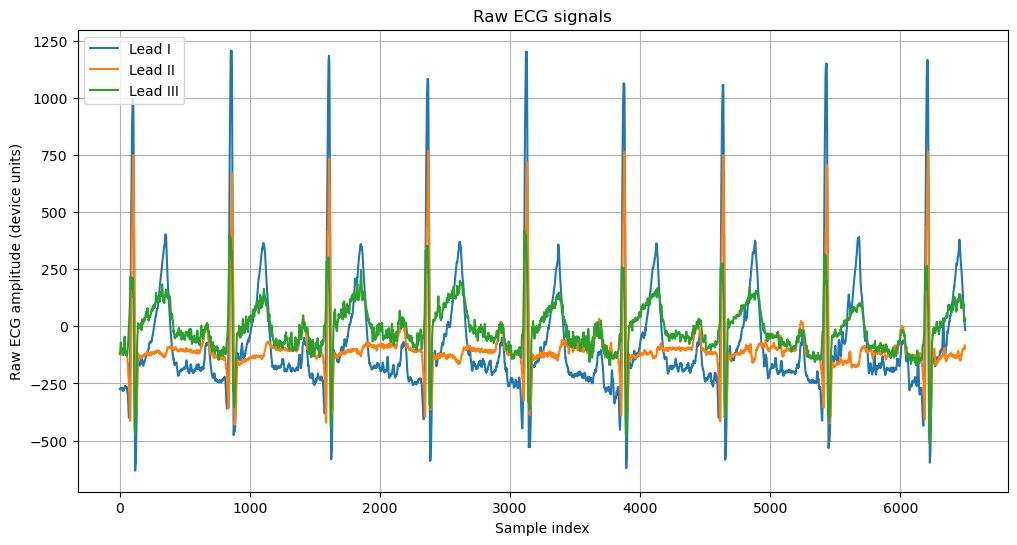

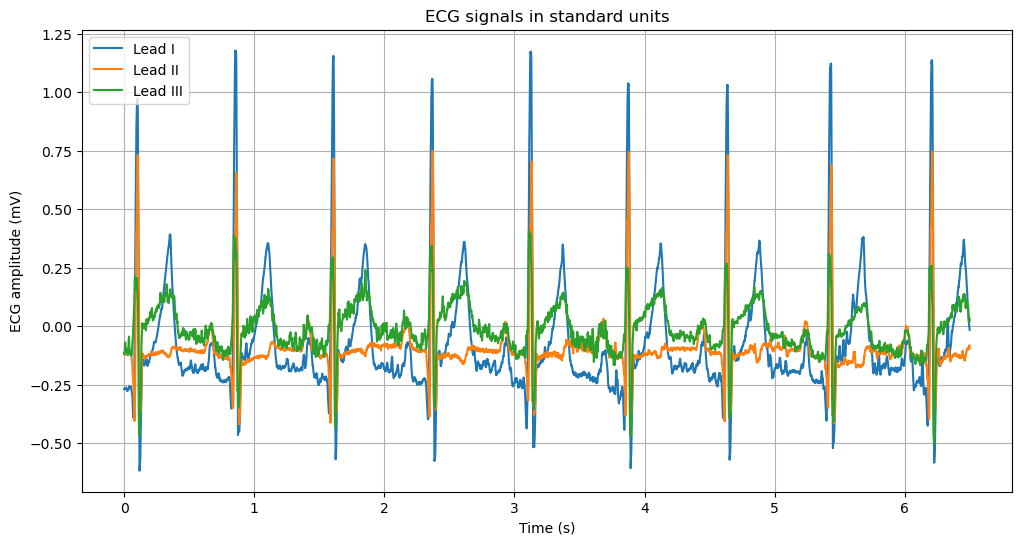

In [12]:
# use the functions that were defined above

# Store the location of the ECG data text file.
data_path = "data/ECGu.txt"

# Store the number needed to convert raw ECG values into millivolts.
converter_gain = 1024

# Store the number of ECG measurements recorded every second.
sampling_frequency_hz = 1000 # 1,000 Hz means 1,000 measurements per second.

# Create a list containing the names of the three ECG columns.
lead_names = ["Lead I", "Lead II", "Lead III"]

# Run the load_ecg_data function.
raw_ecg_data = load_ecg_data(data_path) # data_path is placed inside the parentheses because it is the information that the function needs to locate the file. The function returns all the numbers loaded from the file.

# The function returns the converted ECG values.
ecg_data_mv = convert_ecg_to_mv(
    raw_ecg_data,
    converter_gain
)

# These will be used along the horizontal axis of the raw ECG graph.
number_of_samples = raw_ecg_data.shape[0] # raw_ecg_data.shape gives the size of the data: (6500, 3). 6500 rows and 3 columns. [0] selects the first number

# Run the create_time_axis function.
time_seconds = create_time_axis( # It uses the number of samples and the sampling frequency to calculate when each measurement was recorded.
    number_of_samples,
    sampling_frequency_hz
)

# Run the plotting function to create the raw ECG graph.
plot_ecg_signals(
    x_values=sample_indices,                        # Use sample numbers along the bottom.
    ecg_values=raw_ecg_data,                        # Plot the original ECG values.
    lead_names=lead_names,                          # Name the three plotted lines.
    x_axis_label="Sample index",                    # Label the horizontal axis.
    y_axis_label="Raw ECG amplitude (device units)",# Label the vertical axis.
    plot_title="Raw ECG signals"                    # Add the graph title.
)

# Run the same plotting function again to create the rescaled graph.
plot_ecg_signals(
    x_values=time_seconds,                          # Use time in seconds along the bottom.
    ecg_values=ecg_data_mv,                         # Plot the ECG values in millivolts.
    lead_names=lead_names,                          # Name the three plotted lines.
    x_axis_label="Time (s)",                        # Label the horizontal axis.
    y_axis_label="ECG amplitude (mV)",              # Label the vertical axis.
    plot_title="ECG signals in standard units"      # Add the graph title.
)


## 7. Realistic ECG Systems

The purpose of this optional section is to create a graph that resembles the display produced by a real ECG system.

The final figure will contain three subplots arranged vertically:

1. Lead I
2. Lead II
3. Lead III

Each subplot will show time in seconds along the horizontal axis and ECG amplitude in millivolts along the vertical axis.

A traditional ECG-style grid will be placed behind each signal:

- Darker vertical lines every 0.2 seconds.
- Darker horizontal lines every 0.5 millivolts.
- Lighter vertical lines every 0.04 seconds.
- Lighter horizontal lines every 0.1 millivolts.

The lighter intervals are one-fifth of the darker intervals, creating the appearance of standard ECG paper.

### Planned code structure

The code will be divided into five functions:

1. `plot_grid` will draw grid lines using the intervals and limits provided to it.
2. `plot_ecg_grid` will create the darker and lighter ECG grid lines.
3. `plot_one_ecg_signal` will draw the signal from one ECG lead.
4. `plot_one_lead_in_subplots` will combine one signal and its ECG grid inside one subplot.
5. `plot_all_leads_in_subplots` will create the complete figure containing Leads I, II, and III.

Dividing the code into smaller functions makes it possible to create and check each part separately before combining them into the final figure.

Resources:

- ECG example: https://ecglibrary.com/norm.php
- Matplotlib plotting: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Matplotlib subplots: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html

In [13]:
# Define first function that draws vertical and horizontal grid lines.
def plot_grid(
    seconds_per_square,  # Distance between vertical lines in seconds.
    mV_per_square,       # Distance between horizontal lines in millivolts.
    alpha,               # Transparency: 0 is invisible and 1 is completely solid.
    min_time,            # Time at the left side of the grid.
    max_time,            # Time at the right side of the grid.
    min_ecg,             # Lowest ECG value shown.
    max_ecg              # Highest ECG value shown.
):

    # Create the positions of the vertical grid lines.
    vertical_line_positions = np.arange(
        min_time,                           # Start at the minimum time.
        max_time + seconds_per_square,      # Continue until the maximum time is included.
        seconds_per_square                  # Leave this amount of time between each line.
    )

    # Repeat the following instruction for every vertical line position.
    for time_position in vertical_line_positions:

        # Draw one vertical red line at the current time position.
        plt.axvline(
            x=time_position,  # Position of the line on the time axis.
            color="red",      # Make the line red like traditional ECG paper.
            alpha=alpha,      # Use the transparency provided to the function.
            linewidth=0.8,    # Set the thickness of the line.
            zorder=0          # Place the grid behind the ECG signal.
        )

    # Create the positions of the horizontal grid lines.
    horizontal_line_positions = np.arange(
        min_ecg,                    # Start at the lowest ECG value.
        max_ecg + mV_per_square,    # Continue until the highest ECG value is included.
        mV_per_square               # Leave this voltage interval between each line.
    )

    # Repeat the following instruction for every horizontal line position.
    for ecg_position in horizontal_line_positions:

        # Draw one horizontal red line at the current ECG value.
        plt.axhline(
            y=ecg_position,  # Position of the line on the ECG amplitude axis.
            color="red",     # Make the line red like traditional ECG paper.
            alpha=alpha,     # Use the transparency provided to the function.
            linewidth=0.8,   # Set the thickness of the line.
            zorder=0         # Place the grid behind the ECG signal.
        )

    # Set the time limits shown on the horizontal axis.
    plt.xlim(min_time, max_time)

    # Set the ECG amplitude limits shown on the vertical axis.
    plt.ylim(min_ecg, max_ecg)

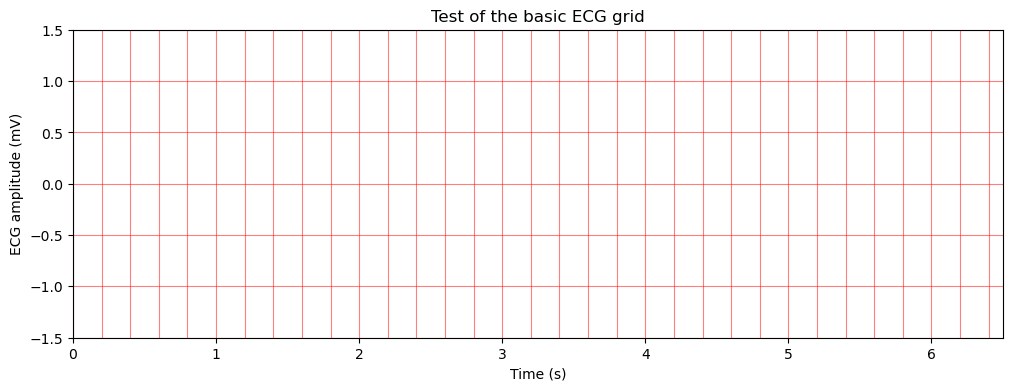

In [ ]:
# Function 1: plot_grid

# Create an empty figure for testing the grid function.
plt.figure(figsize=(12, 4)) # The figure is 12 inches wide and 4 inches high.

# Run the plot_grid function using the larger ECG grid intervals.
plot_grid(
    seconds_per_square=0.2, # Draw a vertical line every 0.2 seconds.
    mV_per_square=0.5,      # Draw a horizontal line every 0.5 millivolts.
    alpha=0.5,              # Make the lines 50% transparent.
    min_time=0,             # Start the time axis at 0 seconds.
    max_time=6.5,           # End the time axis at 6.5 seconds.
    min_ecg=-1.5,           # Show ECG values down to -1.5 mV.
    max_ecg=1.5             # Show ECG values up to 1.5 mV.
)

# Add a title above the test grid.
plt.title("Test of the basic ECG grid")

# Label the horizontal axis.
plt.xlabel("Time (s)")

# Label the vertical axis.
plt.ylabel("ECG amplitude (mV)")

# Display the completed test grid.
plt.show()

In [ ]:
# Function 2: plot_ecg_grid

# Define a second function that creates a complete ECG-paper grid.
def plot_ecg_grid(
    min_time, # Time at the left side of the grid.
    max_time, # Time at the right side of the grid.
    min_ecg,  # Lowest ECG value shown.
    max_ecg   # Highest ECG value shown.
):

# Create the small and large squares of an ECG grid.

    # Use plot_grid to draw the small, light ECG squares.
    plot_grid(
        seconds_per_square=0.04, # Draw a vertical line every 0.04 seconds.
        mV_per_square=0.1,       # Draw a horizontal line every 0.1 mV.
        alpha=0.15,              # Make these grid lines very light.
        min_time=min_time,       # Use the minimum time entered below.
        max_time=max_time,       # Use the maximum time entered below.
        min_ecg=min_ecg,         # Use the lowest ECG value entered below.
        max_ecg=max_ecg          # Use the highest ECG value entered below.
    )

    # Use plot_grid again to draw the large, darker ECG squares.
    plot_grid(
        seconds_per_square=0.2, # Draw a vertical line every 0.2 seconds.
        mV_per_square=0.5,      # Draw a horizontal line every 0.5 mV.
        alpha=0.5,              # Make these grid lines darker.
        min_time=min_time,      # Use the same minimum time.
        max_time=max_time,      # Use the same maximum time.
        min_ecg=min_ecg,        # Use the same lowest ECG value.
        max_ecg=max_ecg         # Use the same highest ECG value.
    )

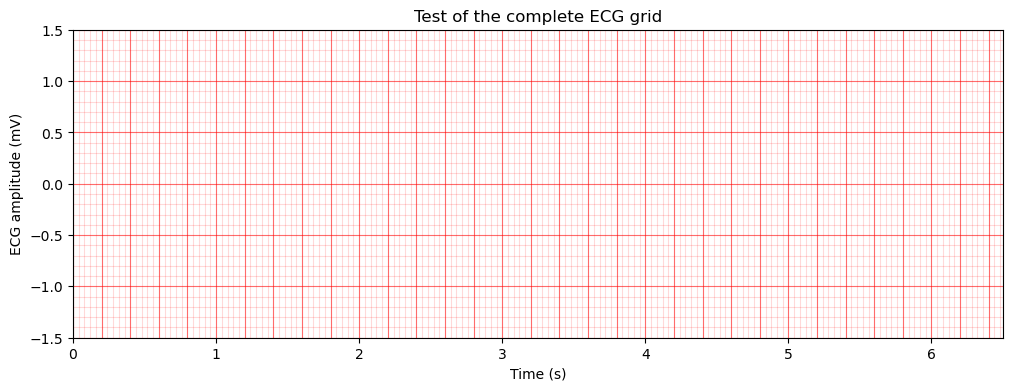

In [16]:
# Create an empty figure for testing the complete ECG grid.
plt.figure(figsize=(12, 4)) # The figure is 12 inches wide and 4 inches high.

# Run plot_ecg_grid to draw the small and large squares.
plot_ecg_grid(
    min_time=0,   # Start the time axis at 0 seconds.
    max_time=6.5, # End the time axis at 6.5 seconds.
    min_ecg=-1.5, # Show ECG values down to -1.5 mV.
    max_ecg=1.5   # Show ECG values up to 1.5 mV.
)

# Add a title above the grid.
plt.title("Test of the complete ECG grid")

# Label the horizontal axis.
plt.xlabel("Time (s)")

# Label the vertical axis.
plt.ylabel("ECG amplitude (mV)")

# Display the completed grid.
plt.show()

In [17]:
#Function 3: Plot one ECG signal

#The `plot_one_ecg_signal` function plots the time values against the ECG values from one lead.
# The ECG line is placed in front of the grid so that the signal remains clearly visible.

# Define a third function that plots the signal from one ECG lead.
def plot_one_ecg_signal(
    time,      # Time values placed along the horizontal axis.
    ecg,       # ECG values placed along the vertical axis.
    lead_name, # Name of the ECG lead.
    color      # Color used to draw the ECG signal.
):
    # Draw the ECG signal over the grid.
    plt.plot(
        time,          # x-value, Use time in seconds along the horizontal axis.
        ecg,           # y-value, Use ECG amplitude in millivolts along the vertical axis.
        color=color,   # Use the color entered when the function is called.
        linewidth=1,   # Set the thickness of the ECG line.
        zorder=2       # Place the ECG signal in front of the grid.
    )

    # Display the name of the ECG lead on the left side of the plot.
    plt.title(
        lead_name,          # Use the lead name entered when the function is called.
        loc="left",         # Place the lead name on the left.
        fontsize=11,        # Set the size of the text.
        fontweight="bold",  # Make the lead name bold.
        color=color         # Use the same color as the ECG signal.
    )

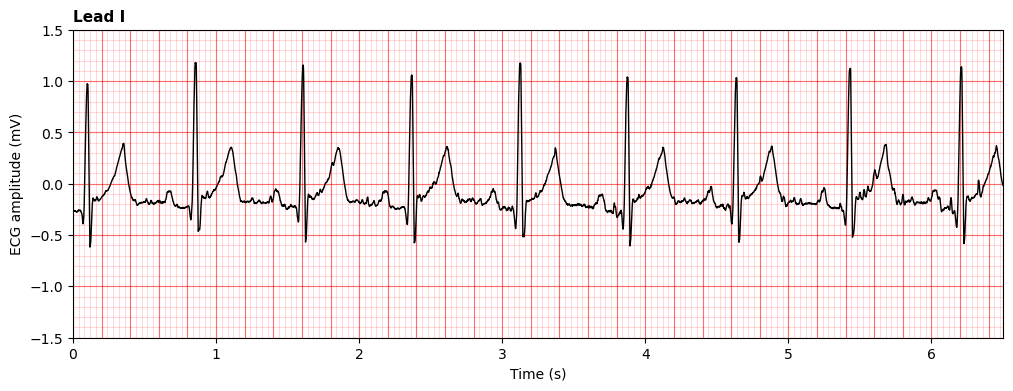

In [18]:
# Create an empty figure for testing one ECG signal.
plt.figure(figsize=(12, 4)) # The figure is 12 inches wide and 4 inches high.

# Draw the complete ECG-paper grid.
plot_ecg_grid(
    min_time=0,   # Start the time axis at 0 seconds.
    max_time=6.5, # End the time axis at 6.5 seconds.
    min_ecg=-1.5, # Show ECG values down to -1.5 mV.
    max_ecg=1.5   # Show ECG values up to 1.5 mV.
)

# Plot Lead I over the ECG grid.
plot_one_ecg_signal(
    time=time_seconds,     # Use the previously created time values.
    ecg=ecg_data_mv[:, 0], # Select every row from column 0, which is Lead I.
    lead_name="Lead I",    # Display Lead I as the name of the signal.
    color="black"          # Draw the ECG signal in black.
)

# Label the horizontal axis.
plt.xlabel("Time (s)")

# Label the vertical axis.
plt.ylabel("ECG amplitude (mV)")

# Display the grid and Lead I signal together.
plt.show()

In [ ]:
# Function 4: Place one ECG lead in a subplot

#A subplot is one smaller graph placed inside a larger figure.

#The final figure will contain three subplot positions:
    #1. The first position will contain Lead I.
    #2. The second position will contain Lead II.
    #3. The third position will contain Lead III.

#The `plot_one_lead_in_subplots` function selects one position and then uses the previous functions to add the ECG grid and signal.

# Define a function that places one ECG lead in one of three subplot positions.
def plot_one_lead_in_subplots(
    subplot,  # Position of the subplot: 1, 2, or 3.
    time,     # Time values used along the horizontal axis.
    ecg,      # ECG values from one lead.
    lead_name,# Name of the ECG lead.
    color     # Color used for the ECG signal.
):
    
    # Create one subplot inside a figure with three rows and one column.
    plt.subplot(
        3,       # Divide the figure into three rows.
        1,       # Use one column.
        subplot  # Select position 1, 2, or 3.
    )

    # Draw the complete ECG-paper grid inside the selected subplot.
    plot_ecg_grid(
        min_time=time[0],  # Use the first time value as the beginning.
        max_time=time[-1], # Use the final time value as the end.
        min_ecg=-1.5,      # Show ECG amplitudes down to -1.5 mV.
        max_ecg=1.5        # Show ECG amplitudes up to 1.5 mV.
    )

    # Draw the selected ECG signal over the grid inside the subplot.
    plot_one_ecg_signal(
        time=time,           # Use the time values given to this function.
        ecg=ecg,             # Use the ECG values given to this function.
        lead_name=lead_name, # Display the selected lead name.
        color=color          # Use the selected signal color.
    )

    # Label the vertical axis in millivolts.
    plt.ylabel("mV")

    # Check whether this is the third and final subplot.
    if subplot == 3:

        # Add the time label only under the final subplot.
        plt.xlabel("Time (s)")

    # Check whether this is the first or second subplot.
    else:

        # Hide the time numbers under the first two subplots.
        # The three subplots use the same time axis, so only the bottom one needs them.
        plt.tick_params(labelbottom=False)

